In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from PF2nlfff.utils.data import samples
LL_data = samples().LL
nx,ny,nz = LL_data.shape[1:]
boundary = LL_data[...,0].copy()
bound_tensor = torch.from_numpy(boundary).float()

In [3]:
import gc
from PF2nlfff import PROGAN
gc.collect()
torch.cuda.empty_cache()
device = 'cuda:1'
progan = PROGAN(bound_tensor,device=device)
res = progan(
    nz = nz,
    nn_config=dict(
        epoch=10000,
        print_epoch=500,
        Delta = 10,
        gamma = 0.994,
        L_div = 1.e-1,
        L_ff  = 1.e-2,
        L_lf  = 1.e-1,
        ),
    )

================================== Extrapolating Potential Field ===================================
 nx:101 | ny:101 | nz:51
 device: cuda:1
Batch Size/Total Size: 105258/520251
 Wall Time:     0.019 [min]


===================================== Fast NLFFF Extrapolation =====================================
 Initial: fi=7.49477e-03 | sj=9.60614e-01 | L=1.46480e+08
 Final  : fi=8.23914e-03 | sj=2.42368e-01 | L=8.22980e+05

 Wall Time:     0.480 [min]
================================== Physics-Reinforced Retraining ===================================
Clip data from torch.Size([3, 101, 101, 51]) to torch.Size([3, 96, 96, 48])
Iter 00001, Loss: 6.555e+06, Loss_div: 5.835e+06,Loss_ff: 1.194e+05, Loss_bc: 5.678e+05, Loss_lf: 3.177e+04, wall_time: 4.672e-01 sec, lr: 1.000e-03
Iter 00500, Loss: 5.648e+03, Loss_div: 3.729e+02,Loss_ff: 3.209e+02, Loss_bc: 4.799e+03, Loss_lf: 2.107e+01, wall_time: 4.996e+01 sec, lr: 7.401e-04
Iter 01000, Loss: 7.209e+02, Loss_div: 2.033e+02,Loss_ff: 1.547e+02, L

In [68]:
from PF2nlfff.utils.data import ShapeClip
from PF2nlfff.utils.visual import BcubeRen
LL_clip = ShapeClip(LL_data)
BcubeRen(LL_clip, './LL/ref/')
BcubeRen(nn_data, './LL/nn/')

./LL/ref/bx_cube.jpg
./LL/ref/by_cube.jpg
./LL/ref/bz_cube.jpg
./LL/ref/bnorm2_cube.jpg
./LL/nn/bx_cube.jpg
./LL/nn/by_cube.jpg
./LL/nn/bz_cube.jpg
./LL/nn/bnorm2_cube.jpg


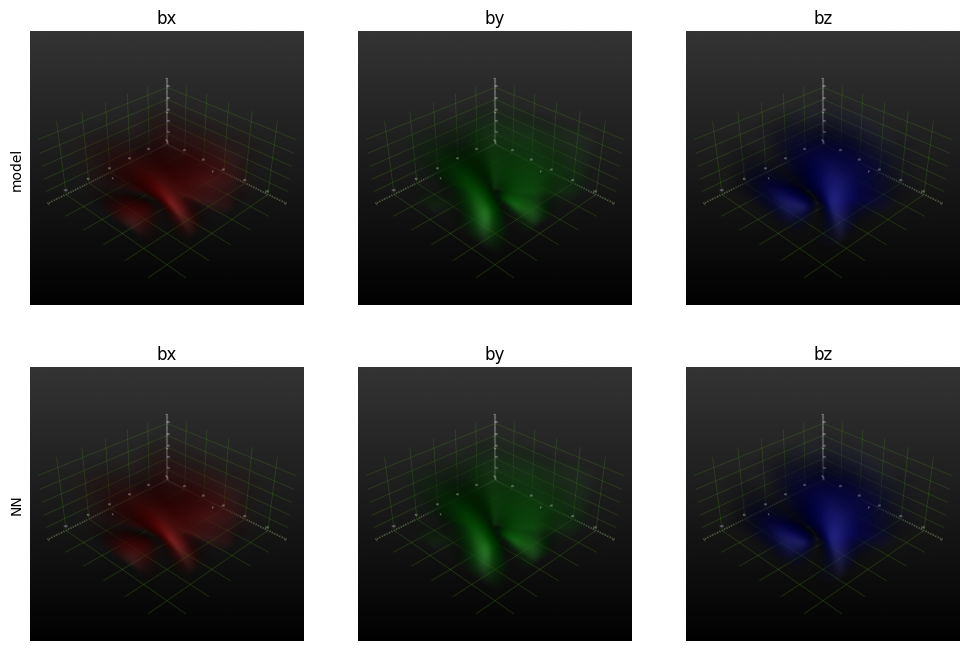

In [ ]:
import cv2
import matplotlib.pyplot as plt
ref_path = './LL/ref/'
nn_path  = './LL/nn'

plt.figure(figsize=(12,8))
for i,bi in enumerate(['bx','by','bz']):
    plt.subplot(2,3,i+1)
    img_path = os.path.join(ref_path, f"{bi}_cube.jpg")
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    plt.imshow(img)
    plt.title(bi)
    if i == 0:
        plt.ylabel('model')
    plt.xticks([])
    plt.yticks([])
    plt.gca().spines[:].set_visible(False)  
    plt.subplot(2,3,i+4)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    plt.imshow(img)
    plt.title(bi)
    if i == 0:
        plt.ylabel('NN')
    plt.xticks([])
    plt.yticks([])
    plt.gca().spines[:].set_visible(False)

plt.show()
